# Feature Engineering, Pipelines, and Tuning with sktime

This session covers:

- Time series transformers (in the sklearn sense)
- Manual feature engineering (what not to do)
- Forecasting pipelines
- Time-aware cross-validation
- Hyperparameter tuning


In [1]:
#!pip install -U sktime matplotlib pandas seaborn statsmodels

In [95]:
3600*24

86400

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sktime.utils.plotting import plot_series, plot_windows

from sktime.datasets import load_airline
from sktime.forecasting.model_selection import (
    temporal_train_test_split,
    ForecastingGridSearchCV,
    ExpandingWindowSplitter,
)

from sktime.performance_metrics.forecasting import MeanSquaredError
from sktime.forecasting.compose import make_reduction, ForecastingPipeline
from sktime.transformations.series.lag import Lag
from sktime.forecasting.base import ForecastingHorizon

from sklearn.linear_model import Ridge


## Load and visualize data

In [9]:
# TODO: load airline dataset and plot it

y = load_airline()

<Axes: >

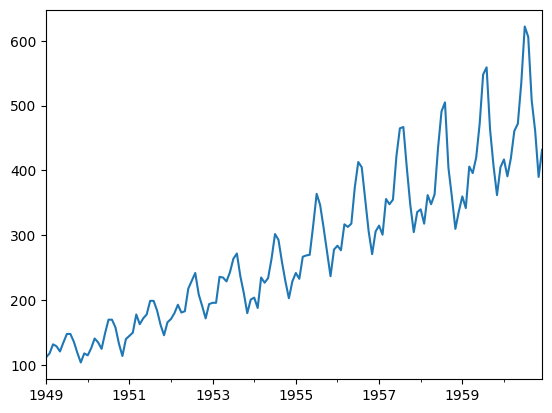

In [12]:
type(y)

y.plot()


- standard time series data
- some seasonal variation
- increasing overall trend

## Train/Test Split

In [17]:
# TODO: perform temporal_train_test_split and define fh

# split data into training and testing (use 24 months)
y_train, y_test = temporal_train_test_split(y, test_size=24)

# define forecasting horizon
fh = ForecastingHorizon(y_test.index, is_relative=False) # index is what time period we are talking about

In [18]:
fh # testing up to 2 years

ForecastingHorizon(['1959-01', '1959-02', '1959-03', '1959-04', '1959-05', '1959-06',
             '1959-07', '1959-08', '1959-09', '1959-10', '1959-11', '1959-12',
             '1960-01', '1960-02', '1960-03', '1960-04', '1960-05', '1960-06',
             '1960-07', '1960-08', '1960-09', '1960-10', '1960-11', '1960-12'],
            dtype='period[M]', is_relative=False)

- is_relative=False: index is the year and the month
- is_relative=True: requires you to set a cutoff (ex at 1958-dec)

## Manual transformations: doing things the wrong way

We manually create lag features outside a forecasting pipeline.


In [27]:
# TODO: manually create lag features

df = pd.DataFrame({"y": y}) # define dataframe with column named y
df['lag1'] = df['y'].shift(1) # create lag 1 feature
df['lag2'] = df['y'].shift(2) # create lag 2 feature
df = df.dropna() # drop rows with missing values - gets rid of first two rows because they have missing values for lag1 and lag2

df.head()

,y,lag1,lag2
1949-03,132.0,118.0,112.0
1949-04,129.0,132.0,118.0
1949-05,121.0,129.0,132.0
1949-06,135.0,121.0,129.0
1949-07,148.0,135.0,121.0


## Reduction-based forecasting

In [28]:
# TODO: build reduction forecaster and generate predictions

# make a forecasting agent that works with sktime
forecaster = make_reduction(
    Ridge(), # choose to use the ridge regression model
    window_length= 12, # use the past 12 months to predict the next month
    strategy = "recursive", # means that if we want to predict more than one step ahead, the model will run that many times
)


In [29]:
forecaster

RecursiveTabularRegressionForecaster(estimator=Ridge(), window_length=12)

In [30]:
forecaster.fit(y_train)

RecursiveTabularRegressionForecaster(estimator=Ridge(), window_length=12)

In [32]:
y_pred = forecaster.predict(fh) # generate predictions for the forecasting horizon of 24 months

In [37]:
#y_pred

(<Figure size 1600x400 with 1 Axes>,
 <Axes: ylabel='Number of airline passengers'>)

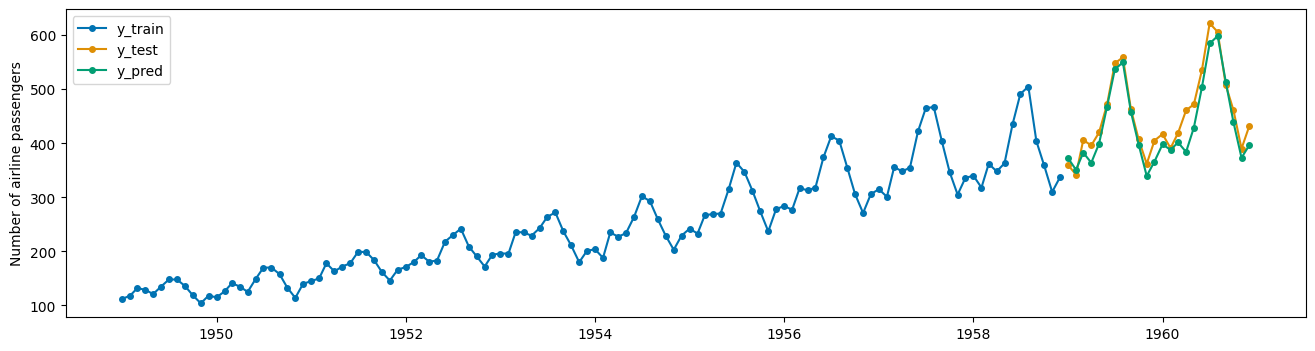

In [34]:
plot_series(y_train, y_test, y_pred, labels=["y_train", "y_test", "y_pred"]) # put down all the things you want to plot

- in practice, we may never exactly know what the seasonality is, so window length might have to be tested

## Forecasting pipeline with Lag transformer

In [35]:
# TODO: build ForecastingPipeline with Lag transformer

pipe = ForecastingPipeline(
    steps=[
        ("lags", Lag([1, 2, 3, 12])), # this creates lag features for the past 1, 2, 3, and 12 months)
        ("model", make_reduction(Ridge(), strategy="recursive")) # make_reduction creates a forecasting agent that works with sktime, and we choose to use the ridge regression model and the recursive strategy
    ]
)

In [36]:
pipe

ForecastingPipeline(steps=[('lags', Lag(lags=[1, 2, 3, 12])),
                           ('model',
                            RecursiveTabularRegressionForecaster(estimator=Ridge()))])

In [38]:
pipe.fit(y_train)
y_pred = pipe.predict(fh)

(<Figure size 1600x400 with 1 Axes>,
 <Axes: ylabel='Number of airline passengers'>)

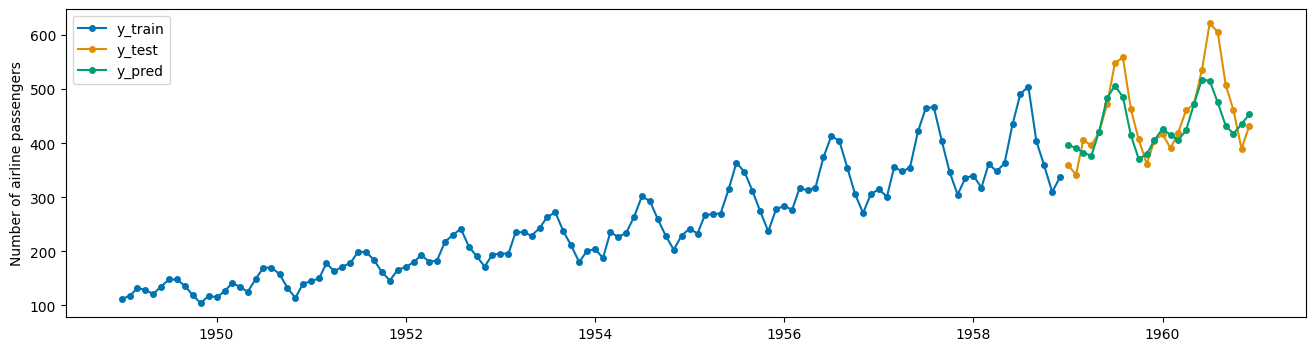

In [39]:
plot_series(y_train, y_test, y_pred, labels=["y_train", "y_test", "y_pred"])

## Time series cross-validation

(<Figure size 1600x480 with 1 Axes>,
 <Axes: xlabel='Time', ylabel='Window number'>)

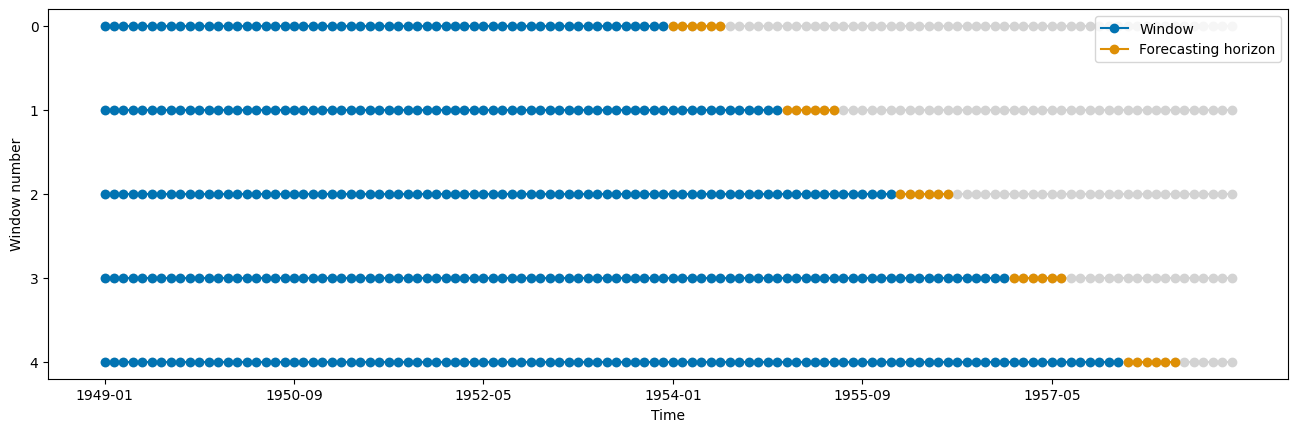

In [40]:
# TODO: set up ExpandingWindowSplitter and ForecastingGridSearchCV


# mostly for visualizing and seeing how we are doing the training
cv = ExpandingWindowSplitter(
    initial_window=60, # how much data we will start with
    step_length=12, # how much we want to move the window each time
    fh=[1,2,3,4,5,6] # how many steps ahead we want to predict each time
)

plot_windows(cv, y_train) # visualize the expanding window splitter on the training data

- fold is advancing by 12 months each time


- so model is trained on all the data together
- but each prediction is only using the lags associated with that time period

In [66]:
param_grid = {
    "lags__lags": [[1, 2, 3], [1, 2, 3, 4], [1, 2, 3, 6, 9, 12], [1, 2, 3, 12]], # different lag features to try
    "model__estimator__alpha": [0.01, 0.1, 1.0, 10.0, 20.0], # different values of alpha for ridge model
}

gscv = ForecastingGridSearchCV(
    forecaster=pipe, # created the forecasting pipeline with the lag transformer and ridge regression model
    param_grid=param_grid, # set up dictionary of parameters to search over
    cv=cv, # created the cross-validation strategy using the expanding window splitter
    scoring=MeanSquaredError(square_root=True), # use root mean squared error as the scoring metric
)

gscv # this is a cross-validated forecaster

ForecastingGridSearchCV(cv=ExpandingWindowSplitter(fh=[1, 2, 3, 4, 5, 6],
                                                   initial_window=60,
                                                   step_length=12),
                        forecaster=ForecastingPipeline(steps=[('lags',
                                                               Lag(lags=[1, 2,
                                                                         3,
                                                                         12])),
                                                              ('model',
                                                               RecursiveTabularRegressionForecaster(estimator=Ridge()))]),
                        param_grid={'lags__lags': [[1, 2, 3], [1, 2, 3, 4],
                                                   [1, 2, 3, 6, 9, 12],
                                                   [1, 2, 3, 12]],
                                    'model__estimator__alpha': [0.01, 0.1, 1.0,
                                                                10.0, 20.0]},
                        scoring=MeanSquaredError(square_root=True))

In [67]:
gscv.fit(y_train) # fit the grid search cross-validation forecaster to the training data

ForecastingGridSearchCV(cv=ExpandingWindowSplitter(fh=[1, 2, 3, 4, 5, 6],
                                                   initial_window=60,
                                                   step_length=12),
                        forecaster=ForecastingPipeline(steps=[('lags',
                                                               Lag(lags=[1, 2,
                                                                         3,
                                                                         12])),
                                                              ('model',
                                                               RecursiveTabularRegressionForecaster(estimator=Ridge()))]),
                        param_grid={'lags__lags': [[1, 2, 3], [1, 2, 3, 4],
                                                   [1, 2, 3, 6, 9, 12],
                                                   [1, 2, 3, 12]],
                                    'model__estimator__alpha': [0.01, 0.1, 1.0,
                                                                10.0, 20.0]},
                        scoring=MeanSquaredError(square_root=True))

In [68]:
# which model to pick?

gscv.get_fitted_params()['best_params'] # get the parameters of the best model found by grid search

{'lags__lags': [1, 2, 3], 'model__estimator__alpha': 20.0}

In [69]:
gscv.best_forecaster_ # directly get the best forecaster found by grid search

ForecastingPipeline(steps=[('lags', Lag(lags=[1, 2, 3])),
                           ('model',
                            RecursiveTabularRegressionForecaster(estimator=Ridge(alpha=20.0)))])

(<Figure size 1600x400 with 1 Axes>,
 <Axes: ylabel='Number of airline passengers'>)

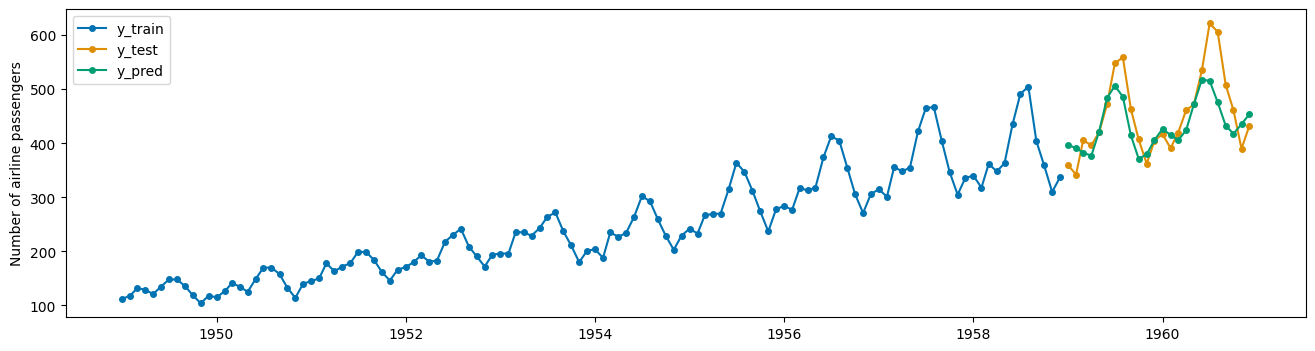

In [72]:
y_pred = gscv.predict(fh) # generate predictions using the best forecaster found by grid search

plot_series(y_train, y_test, y_pred, labels=["y_train", "y_test", "y_pred"]) # plot the training data, test data, and predictions

## Multiple preprocessing methods and pipelining, with ExponentialSmoothing

In [74]:
# TODO: Multiple pipelines comparison

from sktime.forecasting.exp_smoothing import ExponentialSmoothing
from sklearn.preprocessing import PowerTransformer, RobustScaler, MinMaxScaler
from sktime.forecasting.compose import TransformedTargetForecaster
from sktime.transformations.series.adapt import TabularToSeriesAdaptor
from sktime.transformations.series.detrend import Deseasonalizer, Detrender 

In [76]:
forecaster = TransformedTargetForecaster( 
    steps=[
        ("detrender", Detrender()), # this removes the trend from the data
        ("deseasonalizer", Deseasonalizer()), # this removes the seasonality from the data
        ("minmax", TabularToSeriesAdaptor(MinMaxScaler())), # this scales the data using a min-max scaler
        ("power", TabularToSeriesAdaptor(PowerTransformer())), # this applies a power transformation to the data
        ("scaler", TabularToSeriesAdaptor(RobustScaler())), # this applies a robust scaler to the data

        ("forecaster", ExponentialSmoothing()) # this applies the exponential smoothing forecasting model to the data
    ])

- think of this as a pipeline again
- scales each feature from [1,10]
- adapter fits minmax scaler to our shape of data (vector)
- robust scaler is safer from outliers. uses median instead of the mean

- "deseasonalizer" is what i refer to it as, __model refers to what i am trying to change

In [86]:
param_grid = {
    # deseasonalizer
    "deseasonalizer__model": ["additive", "multiplicative"], # different ways to remove seasonality

    # power transformer
    "power__transformer__method": ["yeo-johnson", "box-cox"], # different methods for power transformation
    "power__transformer__standardize": [True, False], # whether to standardize the data after power transformation

    # forecaster
    "forecaster__sp": [4, 6, 12], # different spans for the exponential smoothing model
    "forecaster__seasonal": ["add", "mul"], # different ways to model seasonality in the exponential smoothing model
    "forecaster__trend": ["add", "mul"], # different ways to model trend in the exponential smoothing model 
    "forecaster__damped_trend": [True, False] # whether to use a damped trend in the exponential smoothing model
}

# how many models are we comparing with the param grid? 



In [92]:
gscv = ForecastingGridSearchCV(
    forecaster=forecaster,
    param_grid=param_grid,
    cv=cv,
    verbose=0,
    n_jobs=-1, # use all available CPU cores to speed up the grid search
    scoring=MeanSquaredError(square_root=True),
)

gscv.fit(y_train)

/opt/anaconda3/lib/python3.12/site-packages/sktime/utils/parallel.py:107: FitFailedWarning: 
                In evaluate, fitting of forecaster TransformedTargetForecaster failed,
                you can set error_score='raise' in evaluate to see
                the exception message.
                Fit failed for the 0-th data split, on training data y_train with
                cutoff NaT, and len(y_train)=60.
                The score will be set to nan.
                Failed forecaster with parameters: TransformedTargetForecaster(steps=[('detrender', Detrender()),
                                   ('deseasonalizer', Deseasonalizer()),
                                   ('minmax',
                                    TabularToSeriesAdaptor(transformer=MinMaxScaler())),
                                   ('power',
                                    TabularToSeriesAdaptor(transformer=PowerTransformer(method='box-cox'))),
                                   ('scaler',
               

ForecastingGridSearchCV(cv=ExpandingWindowSplitter(fh=[1, 2, 3, 4, 5, 6],
                                                   initial_window=60,
                                                   step_length=12),
                        forecaster=TransformedTargetForecaster(steps=[('detrender',
                                                                       Detrender()),
                                                                      ('deseasonalizer',
                                                                       Deseasonalizer()),
                                                                      ('minmax',
                                                                       TabularToSeriesAdaptor(transformer=MinMaxScaler())),
                                                                      ('power',
                                                                       TabularToSeriesAdaptor(transformer=PowerTransformer())),
                                                                      ('scaler',
                                                                       Tab...
                        n_jobs=-1,
                        param_grid={'deseasonalizer__model': ['additive',
                                                              'multiplicative'],
                                    'forecaster__damped_trend': [True, False],
                                    'forecaster__seasonal': ['add', 'mul'],
                                    'forecaster__sp': [4, 6, 12],
                                    'forecaster__trend': ['add', 'mul'],
                                    'power__transformer__method': ['yeo-johnson',
                                                                   'box-cox'],
                                    'power__transformer__standardize': [True,
                                                                        False]},
                        scoring=MeanSquaredError(square_root=True))

In [93]:
gscv.get_fitted_params()['best_params'] # get the parameters of the best model found by grid search

{'deseasonalizer__model': 'additive',
 'forecaster__damped_trend': True,
 'forecaster__seasonal': 'add',
 'forecaster__sp': 12,
 'forecaster__trend': 'add',
 'power__transformer__method': 'yeo-johnson',
 'power__transformer__standardize': True}

(<Figure size 1600x400 with 1 Axes>,
 <Axes: ylabel='Number of airline passengers'>)

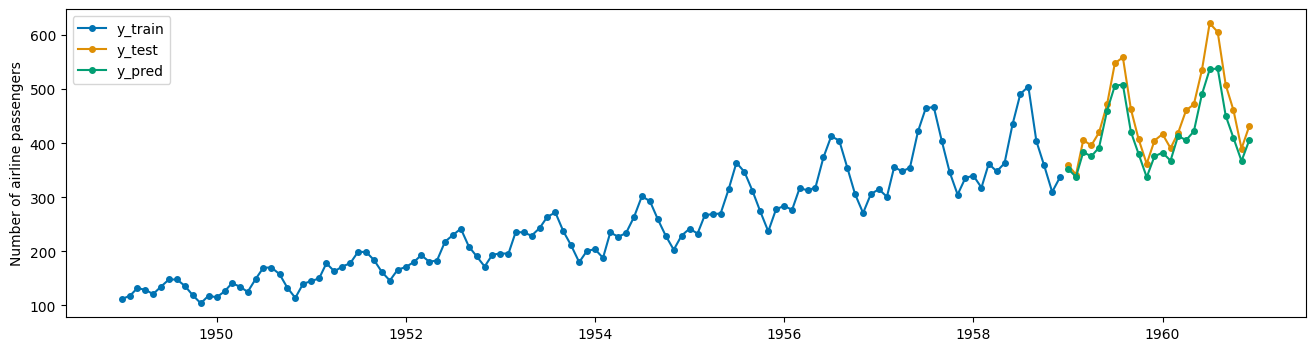

In [94]:
y_pred = gscv.predict(fh)

plot_series(y_train, y_test, y_pred, labels=["y_train", "y_test", "y_pred"])